In [1]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv
import io
from PIL import Image
import glob
import os
import pandas as pd
import matplotlib
matplotlib.style.use('dark_background')
import re
import seaborn as sns
import sys
from datetime import datetime, timedelta
sys.path.append('C:/Seafile/BSc_code/')
from functions import *
import h5py
import scipy
from scipy.spatial.distance import cdist

In [2]:
# Main processing loop for multiple files
pc = 'sophia'
if pc == 'sophia':
    basevol='C:/Seafile/'
    basepath = basevol + '/BSc_data/'
    data_info = basepath + '/data_info/'
    output_folder = basepath + "/processed_data/"
    npz_directory = basepath + 'shark_tracking_data/'
    figures_path = basepath + "figures/"
    mat_file_path = basepath + 'carangids_manual_tracking/tracking/'
else:
    basevol = '/Users/ang/Seafile/'
    basepath = basevol + '/BSc_data/'
    data_info = basepath + '/data_info/'
    output_folder = basepath + "/processed_data/"
    npz_directory = basepath + 'shark_tracking_data/'
    figures_path = basepath + "figures/"
    mat_file_path = basepath + 'carangids_manual_tracking/tracking/'

### Random data

    trajectory  point         x         y
0            A      0  0.000000 -0.475164
1            A      1  0.024490 -0.436984
2            A      2  0.048980 -0.334601
3            A      3  0.073469 -0.234241
4            A      4  0.097959 -0.271646
..         ...    ...       ...       ...
195          D     46  1.102041  0.059927
196          D     47  1.126531  0.006120
197          D     48  1.151020  0.125798
198          D     49  1.175510 -0.008554
199          D     50  1.200000 -0.008400

[200 rows x 4 columns]


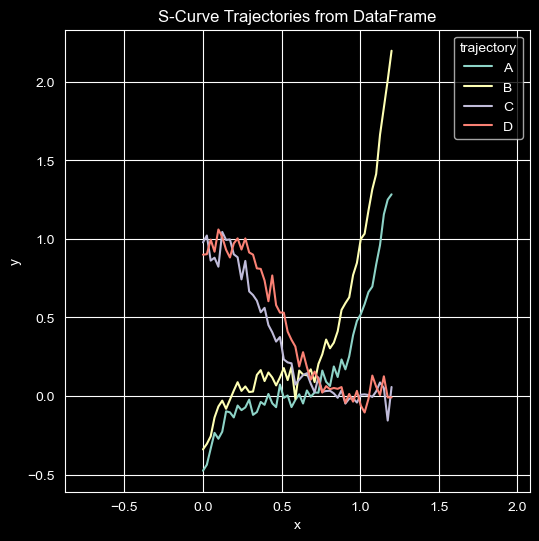

In [3]:
np.random.seed(42)

# Time parameter
t = np.linspace(0, 1.2, 50)

# Generate two S-curve trajectories
x_a = t
y_a = 4 * (t - 0.5)**3 + np.random.normal(0, 0.05, size=50)
trajectory_a = np.stack((x_a, y_a), axis=1)

x_b = t
y_b = 5 * (t - 0.45)**3 + 0.1 + np.random.normal(0, 0.05, size=50)
trajectory_b = np.stack((x_b, y_b), axis=1)

# Combine into DataFrame
df_a = pd.DataFrame({
    'trajectory': 'A',
    'point': np.arange(len(t)),
    'x': x_a,
    'y': y_a
})

df_b = pd.DataFrame({
    'trajectory': 'B',
    'point': np.arange(len(t)),
    'x': x_b,
    'y': y_b
})

np.random.seed(8)

# Time parameter
t = np.linspace(0, 1.2, 50)

# Logistic for trajectory_a (slightly different parameters)
x_a = t
L_a = 1    # slightly higher max
k_a = -9       # slightly less steep
x0_a = 0.4   # small horizontal shift
y_a = L_a / (1 + np.exp(-k_a * (t - x0_a))) + np.random.normal(0, 0.05, size=50)

trajectory_a = np.stack((x_a, y_a), axis=1)


# Logistic curve for trajectory_b
x_b = t
L = 1        # Max value
k = -10       # Steepness
x0 = 0.5     # Midpoint
y_b = L / (1 + np.exp(-k * (t - x0))) + np.random.normal(0, 0.05, size=50)

trajectory_b = np.stack((x_b, y_b), axis=1)


# Combine into DataFrame
df_c = pd.DataFrame({
    'trajectory': 'C',
    'point': np.arange(len(t)) + 2,
    'x': x_a,
    'y': y_a
})

df_d = pd.DataFrame({
    'trajectory': 'D',
    'point': np.arange(len(t)) + 1,
    'x': x_b,
    'y': y_b
})

df = pd.concat([df_a, df_b, df_c, df_d], ignore_index=True)

# Show result
print(df)

# Optional: Plot for visualization
plt.figure(figsize=(6, 6))
sns.lineplot(data=df, x='x', y='y', hue='trajectory', markers=True, dashes=False)
plt.title("S-Curve Trajectories from DataFrame")
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')
plt.show()


#### Velocity caculation

In [4]:
def compute_velocity_uniform(df):
    """
    Compute velocity vectors assuming uniform time steps of 1 between points.
    Assigns velocity from point i to i+1 to point i.
    """
    df = df.sort_values('point').reset_index(drop=True).copy()

    df['vx'] = df['x'].diff().shift(-1).fillna(0)
    df['vy'] = df['y'].diff().shift(-1).fillna(0)

    df['velocity'] = df.apply(lambda row: np.array([row['vx'], row['vy']]), axis=1)

    return df

df_fish_a = compute_velocity_uniform(df[df['trajectory'] == 'A'].copy())
df_fish_b = compute_velocity_uniform(df[df['trajectory'] == 'B'].copy())
df_fish_c = compute_velocity_uniform(df[df['trajectory'] == 'C'].copy())
df_fish_d = compute_velocity_uniform(df[df['trajectory'] == 'D'].copy())


In [5]:
df_fish_c.head()

,trajectory,point,x,y,vx,vy,velocity
0,C,2,0.000000,0.977963,0.02449,0.043662,"[0.024489795918367346, 0.04366150029766358]"
1,C,3,0.024490,1.021625,0.02449,-0.159704,"[0.024489795918367346, -0.1597041950703505]"
2,C,4,0.048980,0.861921,0.02449,0.018492,"[0.024489795918367342, 0.01849227450139712]"
3,C,5,0.073469,0.880413,0.02449,-0.057136,"[0.02448979591836735, -0.057135602136221264]"
4,C,6,0.097959,0.823277,0.02449,0.221213,"[0.02448979591836735, 0.22121312259267312]"


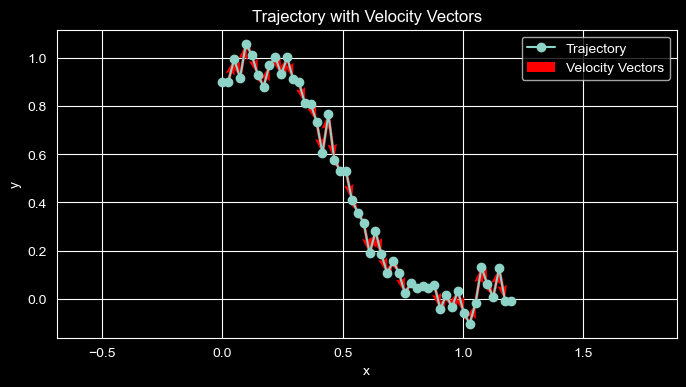

In [6]:
df=df_fish_d
# Visualization
plt.figure(figsize=(8, 4))
plt.plot(df['x'], df['y'], 'o-', label='Trajectory')
plt.quiver(df['x'], df['y'], df['vx'], df['vy'], angles='xy', scale_units='xy', scale=1, color='red', width=0.005, label='Velocity Vectors')

plt.title('Trajectory with Velocity Vectors')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()

#### Correlation caculation

In [6]:
def directional_correlation_time_resolved(df_a, df_b, max_shift=10):
    """
    Compute C(t, τ) = vA(t) · vB(t + τ) for each t in A and τ in [-max_shift, +max_shift].
    Returns a DataFrame with columns: 'point', 'tau', 'correlation'
    """
    df_b = df_b.set_index('point')
    results = []

    for _, row_a in df_a.iterrows():
        t = row_a['point']
        for tau in range(-max_shift, max_shift + 1):
            t_b = t + tau
            if t_b in df_b.index:
                row_b = df_b.loc[t_b]
                dot = row_a['vx'] * row_b['vx'] + row_a['vy'] * row_b['vy']
                results.append({'point': t, 'tau': tau, 'correlation': dot})
            else:
                results.append({'point': t, 'tau': tau, 'correlation': np.nan})

    return pd.DataFrame(results)

def directional_correlation_cosine(df_a, df_b, max_shift=2):
    """
    Compute cosine similarity C(t, τ) = cos(θ) = dot(vA(t), vB(t+τ)) / (||vA|| * ||vB||)
    for each t in A and shift τ. Returns a DataFrame: [point, tau, correlation]
    """
    df_b = df_b.set_index('point')
    results = []

    for _, row_a in df_a.iterrows():
        t = row_a['point']
        va = np.array([row_a['vx'], row_a['vy']])
        norm_va = np.linalg.norm(va)
        if norm_va == 0:
            continue  # skip zero vectors

        for tau in range(-max_shift, max_shift + 1):
            t_b = t + tau
            if t_b in df_b.index:
                row_b = df_b.loc[t_b]
                vb = np.array([row_b['vx'], row_b['vy']])
                norm_vb = np.linalg.norm(vb)
                if norm_vb == 0:
                    continue
                cos_sim = np.dot(va, vb) / (norm_va * norm_vb)
                # clip to [0, 1] if you want only positive similarity
                cos_sim = max(cos_sim, 0)
                results.append({'point': t, 'tau': tau, 'correlation': cos_sim})
            else:
                results.append({'point': t, 'tau': tau, 'correlation': np.nan})

    return pd.DataFrame(results)



In [15]:
from itertools import combinations
import pandas as pd
import numpy as np

def directional_correlation_cosine(df_a, df_b, max_shift=1):
    """
    Compute cosine similarity C(t, τ) = cos(θ) = dot(vA(t), vB(t+τ)) / (||vA|| * ||vB||)
    for each t in A and shift τ. Returns a DataFrame: [point, tau, correlation]
    """
    df_b = df_b.set_index('point')
    results = []

    for _, row_a in df_a.iterrows():
        t = row_a['point']
        va = np.array([row_a['vx'], row_a['vy']])
        norm_va = np.linalg.norm(va)
        if norm_va == 0:
            continue  # skip zero vectors

        for tau in range(-max_shift, max_shift + 1):
            t_b = t + tau
            if t_b in df_b.index:
                row_b = df_b.loc[t_b]
                vb = np.array([row_b['vx'], row_b['vy']])
                norm_vb = np.linalg.norm(vb)
                if norm_vb == 0:
                    continue
                cos_sim = np.dot(va, vb) / (norm_va * norm_vb)
                cos_sim = max(cos_sim, 0)  # clip to [0, 1] for positive similarity only
                results.append({'point': t, 'tau': tau, 'correlation': cos_sim})
            else:
                results.append({'point': t, 'tau': tau, 'correlation': np.nan})

    return pd.DataFrame(results)


def all_directional_correlations_with_cmax(dfs, max_shift=10):
    """
    Compute directional correlation for all unique pairs of trajectories.
    Also compute, for each point and pair, the max correlation and corresponding tau.
    Returns two DataFrames:
        - all_corr_df: detailed correlations for each pair [traj_a, traj_b, point, tau, correlation]
        - cmax_df: max correlation and tau per point per pair [traj_a, traj_b, point, tau_max, Cmax]
    """
    results_all = []

    for (name_a, df_a), (name_b, df_b) in combinations(dfs.items(), 2):
        corr_df = directional_correlation_cosine(df_a, df_b, max_shift=max_shift)
        corr_df['traj_a'] = name_a
        corr_df['traj_b'] = name_b

        # Find Cmax and tau_max per point
        cmax_subdf = (
            corr_df.loc[corr_df.groupby('point')['correlation'].idxmax()]
            .rename(columns={'tau': 'tau_max', 'correlation': 'Cmax'})
            .reset_index(drop=True)
        )
        cmax_subdf['traj_a'] = name_a
        cmax_subdf['traj_b'] = name_b

        results_all.append({'corr': corr_df, 'cmax': cmax_subdf})

    # Combine all pairs results into single DataFrames
    all_corr_df = pd.concat([r['corr'] for r in results_all], ignore_index=True)
    cmax_df = pd.concat([r['cmax'] for r in results_all], ignore_index=True)

    return all_corr_df, cmax_df


In [18]:
def directional_correlation_cosine_window(df_a, df_b, max_shift=5, window=10):
    """
    Compute cosine similarity C(t, τ) over a moving window.
    Each vector is a concatenation of vx, vy over `window` points.

    Returns DataFrame with columns: [point, tau, correlation]
    where 'point' is the window center index.
    """
    df_b = df_b.set_index('point')
    results = []

    for i, row_a in df_a.iterrows():
        t = row_a['point']

        # Define window range centered at t
        half_w = window // 2
        t_range = range(t - half_w, t + half_w + 1)
        if len(t_range) != window:
            continue  # skip if window incomplete (edges)

        # Extract window for trajectory A
        if not set(t_range).issubset(df_a['point'].values):
            continue
        window_a = df_a[df_a['point'].isin(t_range)][['vx', 'vy']].values.flatten()
        norm_a = np.linalg.norm(window_a)
        if norm_a == 0:
            continue

        for tau in range(-max_shift, max_shift + 1):
            shifted_range = [tt + tau for tt in t_range]

            if not set(shifted_range).issubset(df_b.index):
                results.append({'point': t, 'tau': tau, 'correlation': np.nan})
                continue

            # Extract window for trajectory B
            window_b = df_b.loc[shifted_range][['vx', 'vy']].values.flatten()
            norm_b = np.linalg.norm(window_b)
            if norm_b == 0:
                continue

            # Cosine similarity
            cos_sim = np.dot(window_a, window_b) / (norm_a * norm_b)
            cos_sim = max(cos_sim, 0)  # optional: only positive correlations

            results.append({'point': t, 'tau': tau, 'correlation': cos_sim})

    return pd.DataFrame(results)


In [10]:
def all_directional_correlations_with_cmax(dfs, max_shift=5, window=10):
    """
    Compute directional correlation (cosine similarity) for all unique pairs of trajectories
    over a moving window of given size.

    For each pair (A,B), compute correlations in both orientations:
        - A as focal (traj_a=A, traj_b=B)
        - B as focal (traj_a=B, traj_b=A)

    Returns two DataFrames:
        - all_corr_df: detailed correlations for each pair
          [traj_a, traj_b, point, tau, correlation]
        - cmax_df: max correlation and tau per point per pair
          [traj_a, traj_b, point, tau_max, Cmax]
    """
    results_corr = []
    results_cmax = []

    for (name_a, df_a), (name_b, df_b) in combinations(dfs.items(), 2):

        # --- Orientation 1: A as focal ---
        corr_df1 = directional_correlation_cosine_window(df_a, df_b, max_shift=max_shift, window=window)
        corr_df1['traj_a'] = name_a
        corr_df1['traj_b'] = name_b

        # Drop rows where correlation is NaN before taking idxmax
        corr_df1_valid = corr_df1.dropna(subset=['correlation'])
        if not corr_df1_valid.empty:
            cmax_df1 = (
                corr_df1_valid.loc[corr_df1_valid.groupby('point')['correlation'].idxmax()]
                .rename(columns={'tau': 'tau_max', 'correlation': 'Cmax'})
                .reset_index(drop=True)
            )
            cmax_df1['traj_a'] = name_a
            cmax_df1['traj_b'] = name_b
            results_cmax.append(cmax_df1)
        results_corr.append(corr_df1)

        # --- Orientation 2: B as focal ---
        corr_df2 = directional_correlation_cosine_window(df_b, df_a, max_shift=max_shift, window=window)
        corr_df2['traj_a'] = name_b
        corr_df2['traj_b'] = name_a

        corr_df2_valid = corr_df2.dropna(subset=['correlation'])
        if not corr_df2_valid.empty:
            cmax_df2 = (
                corr_df2_valid.loc[corr_df2_valid.groupby('point')['correlation'].idxmax()]
                .rename(columns={'tau': 'tau_max', 'correlation': 'Cmax'})
                .reset_index(drop=True)
            )
            cmax_df2['traj_a'] = name_b
            cmax_df2['traj_b'] = name_a
            results_cmax.append(cmax_df2)
        results_corr.append(corr_df2)

    # Combine all results
    all_corr_df = pd.concat(results_corr, ignore_index=True)
    cmax_df = pd.concat(results_cmax, ignore_index=True)

    return all_corr_df, cmax_df



In [19]:
# Your trajectory DataFrames stored in a dict with labels
dfs = {
    'A': df_fish_a,
    'B': df_fish_b,
    'C': df_fish_c,
    'D': df_fish_d # add more if needed
}

all_corr_df, cmax_df = all_directional_correlations_with_cmax(dfs, max_shift=10)

# Example: show the max correlation info
cmax_df.groupby('traj_a').count()


,point,tau_max,Cmax,traj_b
traj_a,,,,
A,147,147,147,147
B,98,98,98,98
C,49,49,49,49


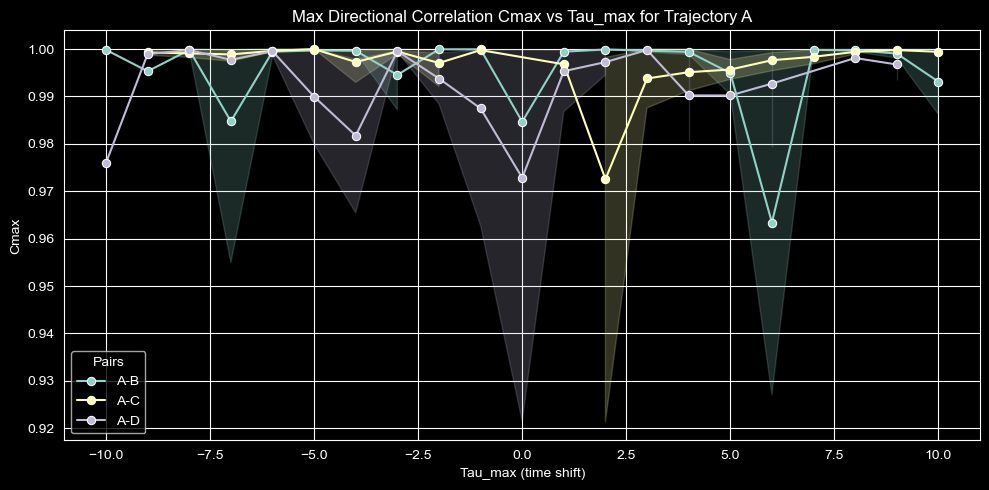

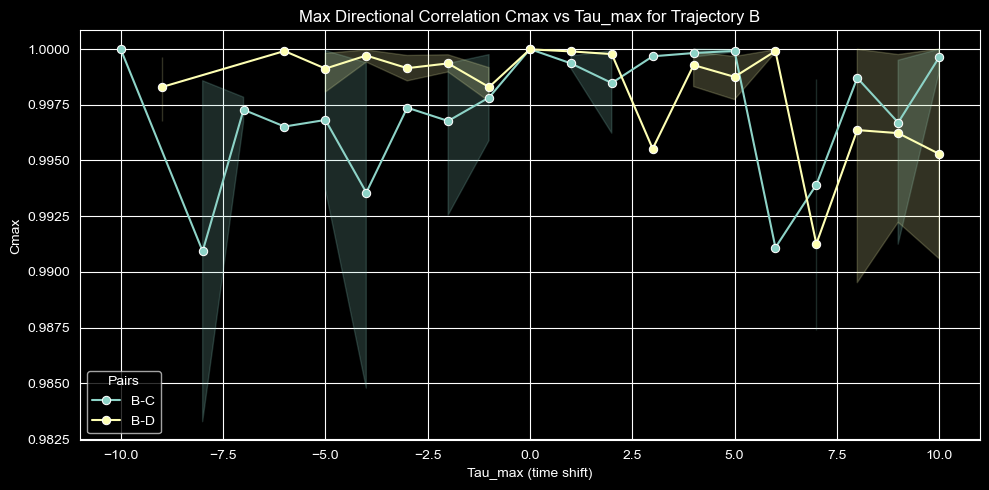

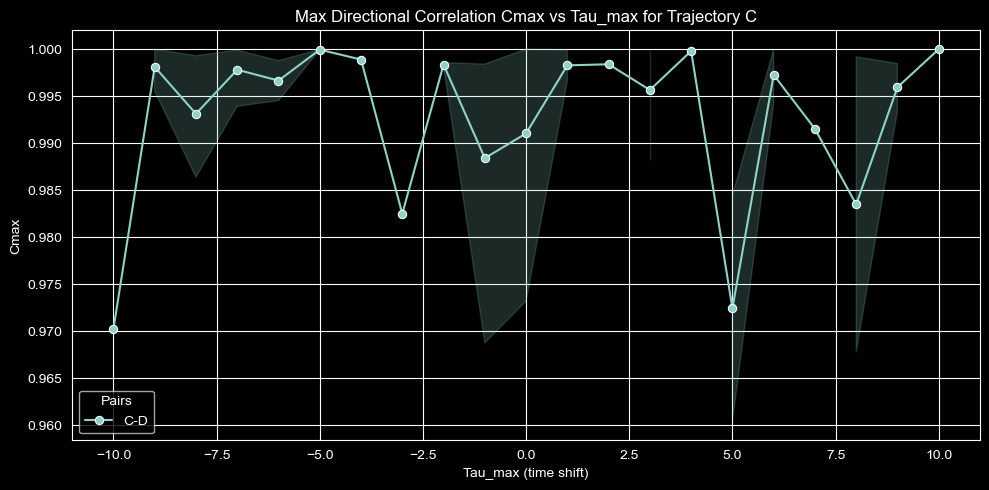

C:\Users\sophi\AppData\Local\Temp\ipykernel_28036\4177312539.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Pairs")


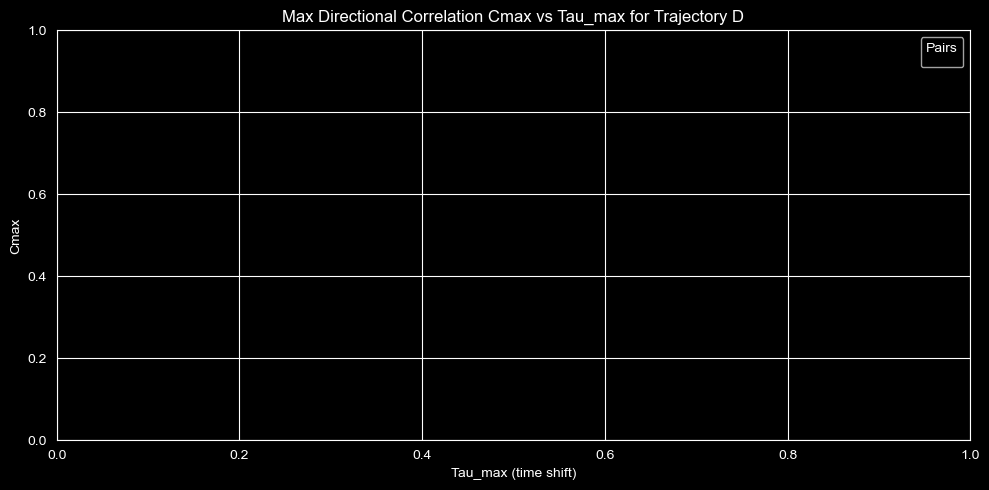

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cmax_per_trajectory(cmax_df, trajectories):
    """
    Plot Cmax over points for each trajectory.
    For each trajectory, plot all pairs where it is traj_a or traj_b.

    Parameters:
    - cmax_df: DataFrame with columns [traj_a, traj_b, point, tau_max, Cmax]
    - trajectories: list of trajectory names, e.g. ['A', 'B', 'C', 'D']
    """
    for traj in trajectories:
        plt.figure(figsize=(10, 5))
        # Filter rows where traj participates
        mask = (cmax_df['traj_a'] == traj) | (cmax_df['traj_b'] == traj)
        subset = cmax_df[mask].copy()

        # Create a new column for pair label (e.g. 'A-B' or 'B-A')
        subset['pair'] = subset.apply(
            lambda row: f"{row['traj_a']}-{row['traj_b']}", axis=1
        )

        sns.lineplot(
            data=subset,
            x='point',
            y='Cmax',
            hue='pair',
            marker='o'
        )

        plt.title(f"Max Directional Correlation Cmax over Time for Trajectory {traj}")
        plt.xlabel("Point (time)")
        plt.ylabel("Cmax")
        plt.legend(title="Pairs")
        plt.tight_layout()
        plt.show()

def plot_cmax_vs_tau_line_per_trajectory(cmax_df, trajectories):
    """
    Plot lineplot of Cmax against tau_max for each trajectory,
    with one line per pair where that trajectory is focal (traj_a).
    """
    for traj in trajectories:
        plt.figure(figsize=(10, 5))

        # Only keep rows where focal trajectory is traj_a
        subset = cmax_df[cmax_df['traj_a'] == traj].copy()
        subset['pair'] = subset.apply(lambda row: f"{row['traj_a']}-{row['traj_b']}", axis=1)

        # Sort for smooth lines
        subset = subset.sort_values(['pair', 'tau_max'])

        sns.lineplot(
            data=subset,
            x='tau_max',
            y='Cmax',
            hue='pair',
            marker='o'
        )

        plt.title(f"Max Directional Correlation Cmax vs Tau_max for Trajectory {traj}")
        plt.xlabel("Tau_max (time shift)")
        plt.ylabel("Cmax")
        plt.legend(title="Pairs")
        plt.tight_layout()
        plt.show()



# Usage:
trajectories = ['A', 'B', 'C', 'D']  # list all your trajectories
plot_cmax_vs_tau_line_per_trajectory(cmax_df, trajectories)


In [14]:
def directional_correlation_cosine_window(df_a, df_b, max_shift=2, window=6):
    """
    Compute cosine similarity C(t, τ) over a moving window.
    Each vector is a concatenation of vx, vy over `window` points.

    Returns DataFrame with columns: [point, tau, correlation]
    where 'point' is the window center index.
    """
    df_b = df_b.set_index('point')
    results = []

    for i, row_a in df_a.iterrows():
        t = row_a['point']

        # Define window range centered at t
        half_w = window // 2
        t_range = range(t - half_w, t + half_w + 1)
        if len(t_range) != window:
            continue  # skip if window incomplete (edges)

        # Extract window for trajectory A
        if not set(t_range).issubset(df_a['point'].values):
            continue
        window_a = df_a[df_a['point'].isin(t_range)][['vx', 'vy']].values.flatten()
        norm_a = np.linalg.norm(window_a)
        if norm_a == 0:
            continue

        for tau in range(-max_shift, max_shift + 1):
            shifted_range = [tt + tau for tt in t_range]

            if not set(shifted_range).issubset(df_b.index):
                results.append({'point': t, 'tau': tau, 'correlation': np.nan})
                continue

            # Extract window for trajectory B
            window_b = df_b.loc[shifted_range][['vx', 'vy']].values.flatten()
            norm_b = np.linalg.norm(window_b)
            if norm_b == 0:
                continue

            # Cosine similarity
            cos_sim = np.dot(window_a, window_b) / (norm_a * norm_b)
            cos_sim = max(cos_sim, 0)  # optional: only positive correlations

            results.append({'point': t, 'tau': tau, 'correlation': cos_sim})

    return pd.DataFrame(results)


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the full C(t, tau)
corr_df = directional_correlation_cosine_window(df_fish_a, df_fish_d, max_shift=2)

# Pivot to a 2D matrix: rows = point (time), columns = tau
corr_matrix = corr_df.pivot(index='point', columns='tau', values='correlation')

# Plot the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title("Directional Correlation C(t, τ)")
plt.xlabel("Time Shift τ")
plt.ylabel("Time t (point)")
plt.tight_layout()
plt.show()


KeyError: 'point'

In [49]:
# Find Cmax and the τ at which it occurs for each point
cmax_df = (
    corr_df.loc[corr_df.groupby("point")["correlation"].idxmax()]
    .rename(columns={"correlation": "Cmax"})
    .reset_index(drop=True)
)

print(cmax_df)


KeyError: 'point'

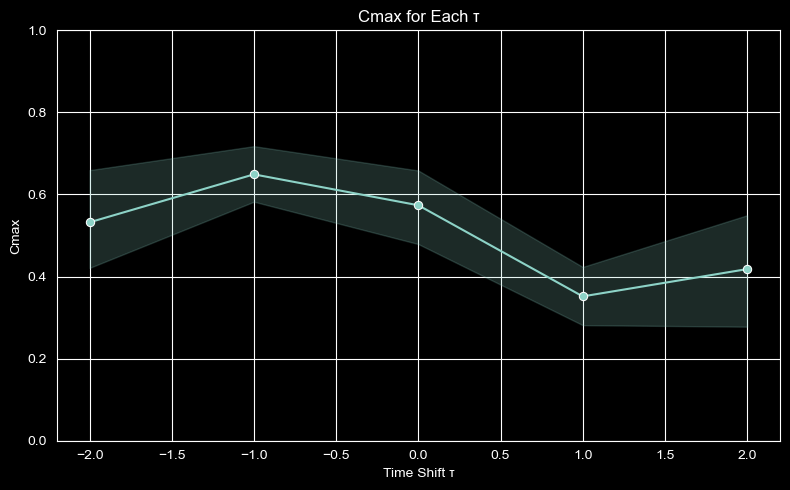

In [46]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=cmax_df, x="tau", y="Cmax", marker="o")
plt.title("Cmax for Each τ")
plt.xlabel("Time Shift τ")
plt.ylabel("Cmax")
plt.ylim(0, 1)  # cosine similarity range
plt.tight_layout()
plt.show()
